<a href="https://colab.research.google.com/github/Sample-droid/01/blob/main/StoreSuperset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"justanotherone701","key":"bc21c0b2b4ea89a12ff58e77991a3ee2"}'}

In [ ]:
import os
os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)
print("Done! Kaggle is ready.")

Done! Kaggle is ready.


In [ ]:
os.system("pip install kaggle -q")
os.system("kaggle datasets download -d vivek468/superstore-dataset-final --unzip");
print("Dataset downloaded");

Dataset downloaded


In [ ]:
import pandas as pd

df=pd.read_csv("Sample - Superstore.csv", encoding="windows-1252")
print("csv file loaded. Here are the first 5 rows")
df.head()

csv file loaded. Here are the first 5 rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print("Rows and Columns:",df.shape)
print("")
print("Column Names")
print(df.columns.tolist())

Rows and Columns: (9994, 21)

Column Names
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Month"]=df["Order Date"].dt.to_period("M")
print("Dates Cleaned")

Dates Cleaned


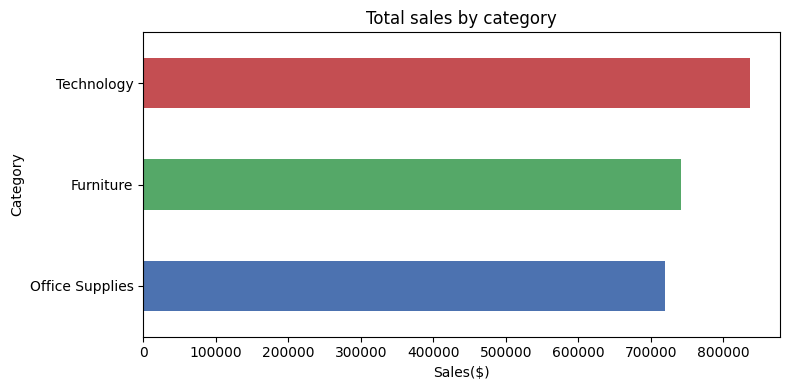

In [ ]:
import matplotlib.pyplot as plt
category_sales=df.groupby("Category")["Sales"].sum().sort_values()
plt.figure(figsize=(8,4))
category_sales.plot(kind="barh", color=["#4C72B0","#55A868","#C44E52"])
plt.title("Total sales by category")
plt.xlabel("Sales($)")
plt.tight_layout()
plt.show()

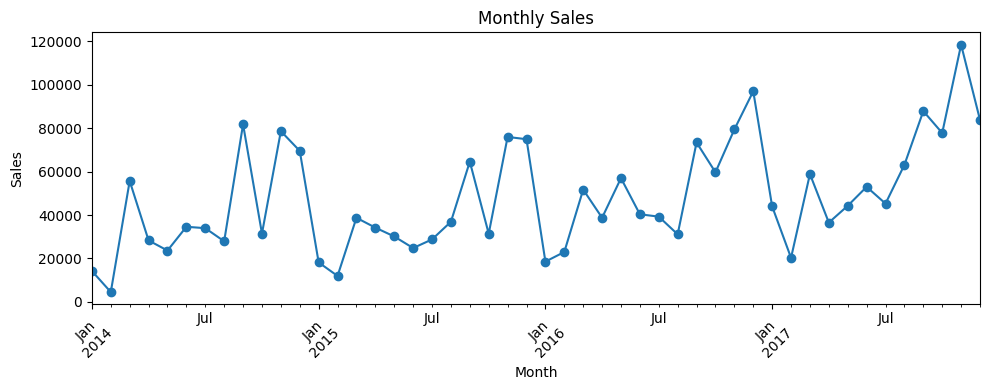

In [ ]:
monthly_sales=df.groupby("Month") ["Sales"].sum()
plt.figure(figsize=(10,4))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:

print("======= YOUR DASHBOARD SUMMARY =======")
print(f"Total Sales:  ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Orders: {df['Order ID'].nunique()}")
print(f"Best Category: {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"Best Region:   {df.groupby('Region')['Sales'].sum().idxmax()}")

======= YOUR DASHBOARD SUMMARY =======
Total Sales:  $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Best Category: Technology
Best Region:   West


# Sales Performance Dashboard
### By Aswin

## Project Goal
Analyze retail sales data to find top products,
best regions, and monthly trends.

## Dataset
Superstore Sales Dataset from Kaggle

## Tools Used
- Python, Pandas, Matplotlib, Seaborn